In [1]:
import scanpy as sc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.sparse import issparse 
import mudata as md
import os

os.chdir("/data/home/scxl504/run/GAT/sc")
dataset = "LUNG-CITE"


### Load data

In [2]:

rna_adata = sc.read_h5ad(os.path.join("data", "raw", dataset, f"{dataset}_RNA.h5ad"))
# peaks_adata = sc.read_h5ad(os.path.join("data", "raw", dataset, f"{dataset}_Peaks.h5ad"))
adt_adata =sc.read_h5ad(os.path.join("data", "raw", dataset, f"{dataset}_ADT.h5ad"))
latent = np.load(
    os.path.join("results", "embedding", f"{dataset}_latent_embedding.npy")
)



### Create mudata

In [3]:
latent_adata = sc.AnnData(
    X=latent,
    obs=rna_adata.obs.copy(),
)

latent_adata.obs_names = rna_adata.obs_names.copy()
latent_adata.var_names = [
    f"latent_{i}" for i in range(latent_adata.n_vars)
]

# create MuData
mdata = md.MuData(
    {
        "rna": rna_adata,
        # "peaks": peaks_adata,
        "adt:": adt_adata,
        "latent": latent_adata,
    }
)

# mdata.update()
print(mdata)

MuData object with n_obs × n_vars = 10470 × 34078
  3 modalities
    rna:	10470 × 33514
      obs:	'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'tissue', 'group', 'volume', 'sampleID', 'celltype', 'nCount_ADT', 'nFeature_ADT'
      var:	'vst.mean', 'vst.variance', 'vst.variance.expected', 'vst.variance.standardized', 'vst.variable'
    adt::	10470 × 52
      obs:	'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'tissue', 'group', 'volume', 'sampleID', 'celltype', 'nCount_ADT', 'nFeature_ADT'
      var:	'count', 'percentile', 'vst.mean', 'vst.variance', 'vst.variance.expected', 'vst.variance.standardized', 'vst.variable'
    latent:	10470 × 512
      obs:	'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'tissue', 'group', 'volume', 'sampleID', 'celltype', 'nCount_ADT', 'nFeature_ADT'


/data/run01/scxl504/conda_envs/sc/lib/python3.10/site-packages/mudata/_core/mudata.py:1471: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
  self._update_attr("var", axis=0, join_common=join_common)
/data/run01/scxl504/conda_envs/sc/lib/python3.10/site-packages/mudata/_core/mudata.py:613: UserWarning: Cannot join columns with the same name because var_names are intersecting.
  self._update_attr_legacy(attr, axis, join_common, **kwargs)
/data/run01/scxl504/conda_envs/sc/lib/python3.10/site-packages/mudata/_core/mudata.py:1322: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new

### Visualization

/data/run01/scxl504/conda_envs/sc/lib/python3.10/site-packages/scanpy/neighbors/__init__.py:577: UserWarning: You’re trying to run this on 512 dimensions of `.X`, if you really want this, set `use_rep='X'`.
         Falling back to preprocessing with `sc.pp.pca` and default params.
  x = _choose_representation(self._adata, use_rep=use_rep, n_pcs=n_pcs)
/data/run01/scxl504/conda_envs/sc/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


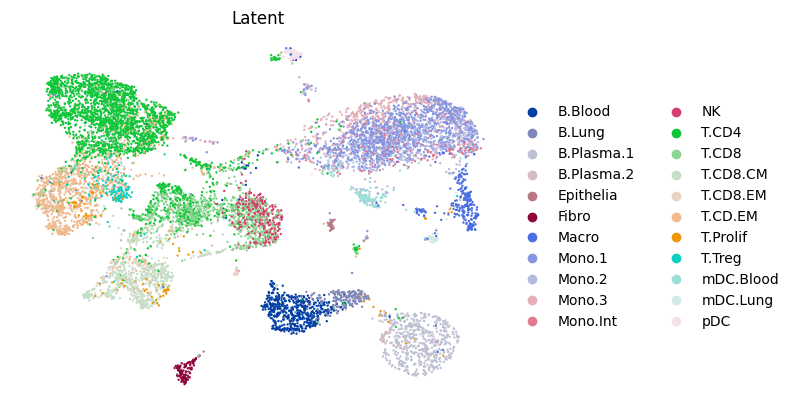

In [4]:
# compute UMAP for latent embedding
sc.pp.neighbors(mdata["latent"], metric="cosine", n_neighbors=15) 
# metric can be changed to "euclidean" or "cosine"
sc.tl.umap(mdata["latent"], random_state=42)
# visualize UMAP for latent embedding
sc.pl.umap(
    mdata["latent"],
    color="celltype",
    frameon=False,
    title="Latent",
)

In [5]:
# # RNA 
# # RNA PCA
# sc.pp.pca(
#     mdata["rna"],
#     n_comps=50
# )

# # RNA neighbors
# sc.pp.neighbors(
#     mdata["rna"],
#     n_neighbors=15,
#     metric="cosine",
#     use_rep="X_pca"
# )

# # RNA UMAP
# sc.tl.umap(
#     mdata["rna"],
#     random_state=42
# )

# # # Plot
# # sc.pl.umap(
# #     mdata["rna"],
# #     color="celltype",
# #     frameon=False,
# #     title=f"{dataset} RNA",
# # )

# fig = sc.pl.umap(
#     mdata["rna"],
#     color="celltype",
#     frameon=False,
#     title=f"{dataset} RNA",
#     return_fig=True,
# )
# if isinstance(fig, tuple):
#     fig = fig[0]
# out_dir = os.path.join("results", "figures")
# os.makedirs(out_dir, exist_ok=True)
# out_path = os.path.join(out_dir, f"{dataset}_RNA_umap.png")
# fig.savefig(out_path, dpi=300, bbox_inches="tight")
# plt.close(fig)

In [ ]:
# # Peaks 
# sc.pp.pca(
#     mdata["peaks"],
#     n_comps=50
# )

# sc.pp.neighbors(
#     mdata["peaks"],
#     metric="cosine",
#     n_neighbors=15,
#     use_rep="X_pca"
# )

# sc.tl.umap(
#     mdata["peaks"],
#     random_state=42
# )

# # sc.pl.umap(
# #     mdata["peaks"],
# #     color="celltype",
# #     frameon=False,
# #     title=f"{dataset} Peaks",
# # )
# fig = sc.pl.umap(
#     mdata["peaks"],
#     color="celltype",
#     frameon=False,
#     title=f"{dataset} Peaks",
#     return_fig=True,
# )
# if isinstance(fig, tuple):
#     fig = fig[0]
# out_dir = os.path.join("results", "figures")
# os.makedirs(out_dir, exist_ok=True)
# out_path = os.path.join(out_dir, f"{dataset}_Peaks_umap.png")
# fig.savefig(out_path, dpi=300, bbox_inches="tight")
# plt.close(fig)

: 